In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from scipy.stats import norm

In [2]:
def N(x):
    return norm.cdf(x)

def dN(x):
    return norm.pdf(x)

def greeks(S ,K ,T ,r ,sig , q, type = "call"):
    d_1 = (np.log(S / K) + (r - q + 0.5 * sig ** 2) * T) / (sig * np.sqrt(T))
    d_2 = d_1 - sig * np.sqrt(T)   

    gamma = (dN(d_1) * np.exp(-q * T) / (S * sig * np.sqrt(T)))
    vega = S * np.exp(-q * T) * dN(d_1) * np.sqrt(T)

    if type == "call":
        delta = np.exp(-q * T) * N(d_1)
        theta = (-S * sig * np.exp(-q * T) * dN(d_1) / (2 * np.sqrt(T))) - (r * K * np.exp(-r * T) * N(d_2)) + (q * S * np.exp(-q * T) * N(d_1))
        rho = K * T * np.exp(-r * T) * N(d_2)
    elif type == "put":
        delta = np.exp(-q * T) * (N(d_1) - 1)
        theta = (-S * sig * np.exp(-q * T) * dN(d_1) / (2 * np.sqrt(T))) + (r * K * np.exp(-r * T) * N(-d_2)) - (q * S * np.exp(-q * T) * N(-d_1))
        rho = -K * T * np.exp(-r * T) * N(-d_2)
    
    return delta, gamma, theta, vega, rho


In [3]:
# Get current stock price and the options chain data
S = pd.read_csv(r"D:\Quant\Python\aapl_price.txt", header=None).iloc[-1, 0]
print(f"Current stock price: {S}")
option_chain = pd.read_csv(r"D:\Quant\Python\aapl_options_cache.csv")
print(option_chain.head())
expirations = option_chain['expiration'].unique()

Current stock price: 180.0
   strike option_type  expiration  last_price  implied_volatility
0   140.0        call  2026-07-17        40.0            0.238519
1   140.0         put  2026-07-17         1.0            0.238519
2   145.0        call  2026-07-17        35.0            0.235394
3   145.0         put  2026-07-17         1.5            0.235394
4   150.0        call  2026-07-17        30.0            0.232500


C:\Users\natha\AppData\Local\Temp\ipykernel_17196\3470898370.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  option_chain_to_T['delta'] = deltas
C:\Users\natha\AppData\Local\Temp\ipykernel_17196\3470898370.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  option_chain_to_T['gamma'] = gammas
C:\Users\natha\AppData\Local\Temp\ipykernel_17196\3470898370.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

     strike option_type  expiration  last_price  implied_volatility     delta  \
102   140.0        call  2027-01-15        40.0            0.238519  0.928968   
103   140.0         put  2027-01-15         1.0            0.238519  0.928968   
104   145.0        call  2027-01-15        35.0            0.235394  0.905427   
105   145.0         put  2027-01-15         1.5            0.235394  0.905427   
106   150.0        call  2027-01-15        30.0            0.232500  0.875646   

        gamma     theta       vega        rho  
102  0.003552 -6.146280  16.320593  73.919073  
103  0.003552 -6.146280  16.320593  73.919073  
104  0.004654 -7.144700  21.104320  74.032444  
105  0.004654 -7.144700  21.104320  74.032444  
106  0.005903 -8.188855  26.436051  73.387496  


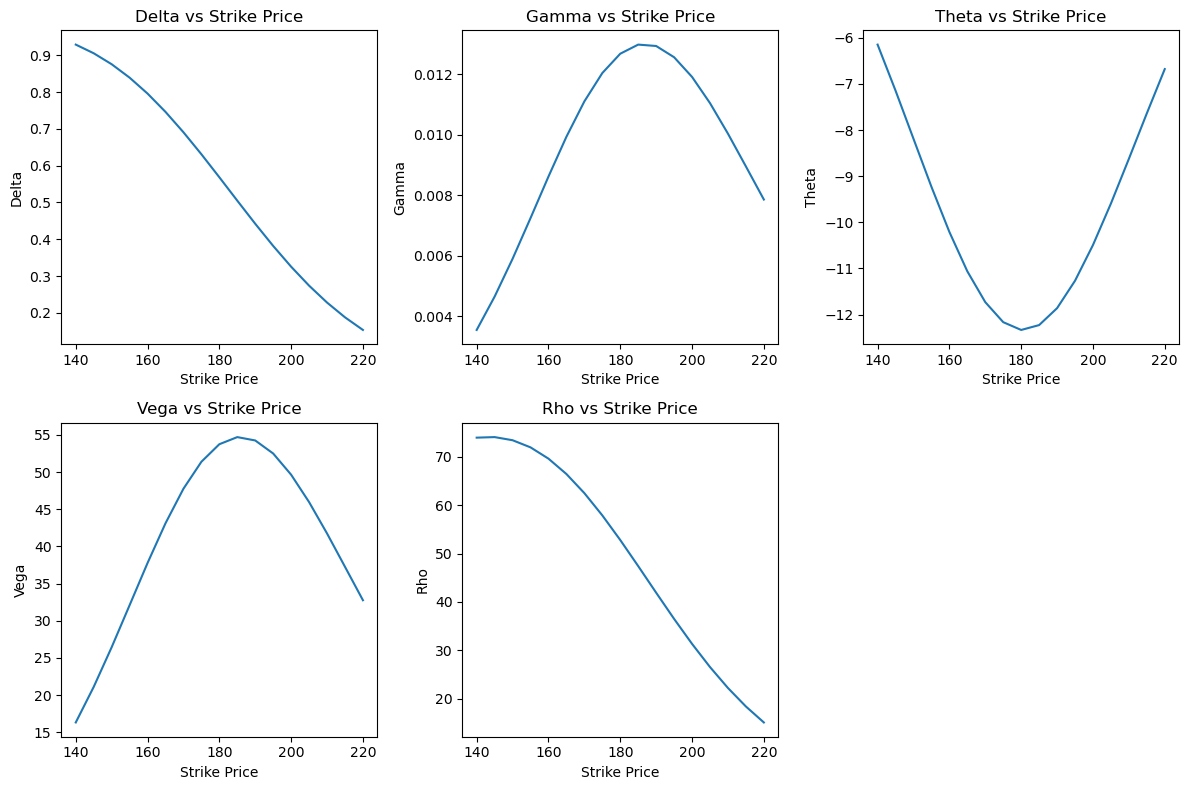

In [13]:
r = 0.05 # risk-free interest rate
q = 0.02 # dividend yield

T = (pd.to_datetime(expirations[-1]) - pd.to_datetime(datetime.now().date())).days / 365 # time to maturity in years (normalized per year, not trading days)
option_chain_to_T = option_chain[option_chain['expiration'] == expirations[-1]]
K = option_chain_to_T['strike'].values # strike prices 
sig = option_chain_to_T['implied_volatility'].values # implied volatilities

deltas, gammas, thetas, vegas, rhos = greeks(S, K, T, r, sig, q, type="call")
option_chain_to_T['delta'] = deltas
option_chain_to_T['gamma'] = gammas
option_chain_to_T['theta'] = thetas
option_chain_to_T['vega'] = vegas
option_chain_to_T['rho'] = rhos
print(option_chain_to_T.head())

plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.plot(K, deltas)
plt.title('Delta vs Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Delta')
plt.subplot(2, 3, 2)
plt.plot(K, gammas)
plt.title('Gamma vs Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Gamma')
plt.subplot(2, 3, 3)
plt.plot(K, thetas)
plt.title('Theta vs Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Theta')
plt.subplot(2, 3, 4)
plt.plot(K, vegas)
plt.title('Vega vs Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Vega')
plt.subplot(2, 3, 5)
plt.plot(K, rhos)
plt.title('Rho vs Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Rho')
plt.tight_layout()
plt.show()